## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pygenn import GeNNModel, VarAccess
from pygenn import (create_neuron_model, create_var_ref, create_weight_update_model, 
                    init_postsynaptic, init_weight_update)

## Parameters

In [2]:
PRE_RATE = 50.0
POST_RATE = 50.0
NUM_POST_STIM = 256

ETA = 0.001

DURATION_MS = 1000
TAU = 20.0
V_THRESH = 0.6

STIM_WEIGHT = 0.0025


## PyGeNN models

In [15]:
lif_model = create_neuron_model(
    "lif",
    params=["TauM", "Vthresh", "TauRefrac"],
    vars=[("V", "scalar"), ("RefracTime", "scalar"), ("E", "scalar"), ("EOld", "scalar")],
    derived_params=[("Alpha", lambda pars, dt: np.exp(-dt / pars["TauM"]))],
    extra_global_params=[("EVec", "scalar*")],
    sim_code="""
    EOld = E;
    E = EVec[(int)t];
    V = (Alpha * V) + Isyn;
    if (RefracTime > 0.0) {
      RefracTime -= dt;
    }
    """,
    reset_code="""
    RefracTime = TauRefrac;
    V -= Vthresh;
    """,
    threshold_condition_code="""
    RefracTime <= 0.0 && V >= Vthresh
    """)
    
eprop_lif_time_model = create_weight_update_model(
    "eprop_lif_time",
    params=["TauE", "Eta"],
    derived_params=[("Alpha", lambda pars, dt: np.exp(-dt / pars["TauE"]))],
    vars=[("g", "scalar"), ("eFiltered", "scalar")],
    pre_vars=[("ZFilter", "scalar")],
    post_vars=[("Psi", "scalar")],
    post_neuron_var_refs=[("RefracTime_post", "scalar"), ("V_post", "scalar"), ("E_post", "scalar")],

    pre_spike_code="""
    ZFilter += 1.0;
    """,
    pre_dynamics_code="""
    ZFilter *= Alpha;
    """,

    post_dynamics_code="""
    if (RefracTime_post > 0.0) {
      Psi = 0.0;
    }
    else {
      Psi = (V_post > 0.3) ? 0.5 : 0.0;
    }
    """,

    synapse_dynamics_code="""
    const scalar e = ZFilter * Psi;
    scalar eF = eFiltered;
    eF = (eF * Alpha) + e;
    g -= Eta * eF * E_post;
    eFiltered = eF;
    """)

eprop_lif_event_model = create_weight_update_model(
    "eprop_lif_event",
    params=["TauE", "Eta"],
    vars=[("g", "scalar"), ("eFiltered", "scalar")],
    pre_vars=[("ZFilter", "scalar")],
    post_vars=[("Psi", "scalar"), ("PsiOld", "scalar")],
    post_neuron_var_refs=[("RefracTime_post", "scalar"), ("V_post", "scalar"), 
                          ("E_post", "scalar"), ("EOld_post", "scalar")],
    
    pre_spike_syn_code="""
    // Get last update time
    // **NOTE** this happens before any postsynaptic update so use prev_set_post
    const timepoint lastUpdateTime = max(prev_st_pre, prev_set_post);
    const timepoint lastUpdateTimePositive = max(0.0, lastUpdateTime);
    
    // Zfilter may have been updated earlier than last update if last update occured on post event
    const scalar zFilterDecay = exp(-(t - st_pre) / TauE);
    
    const scalar decay = exp(-(t - lastUpdateTime) / TauE);
    const scalar tauDecay = TauE * decay;
    const scalar tauDecayMinusOne = TauE * (decay - 1.0);

    // Update weight
    g -= Eta * EOld_post * (
        PsiOld * ZFilter * ((TauE * (TauE + lastUpdateTimePositive)) - (tauDecay * (t + TauE))
                         + lastUpdateTimePositive * tauDecayMinusOne)
        - (eFiltered * tauDecayMinusOne));

    // Update E
    // **NOTE** subtract 1 from ZFilter so we use value before spike
    eFiltered = ((t - lastUpdateTimePositive) * PsiOld * (ZFilter - 1.0) * zFilterDecay) + (eFiltered * decay);
    """,
    
    post_event_syn_code="""
    // **NOTE** this happens after a potential presynaptic update so use st_pre
    const timepoint lastUpdateTime = max(st_pre, prev_set_post);
    const timepoint lastUpdateTimePositive = max(0.0, lastUpdateTime);
    
    const scalar zFilterDecay = exp(-(t - st_pre) / TauE);
    const scalar decay = exp(-(t - lastUpdateTime) / TauE);
    const scalar tauDecay = TauE * decay;
    const scalar tauDecayMinusOne = TauE * (decay - 1.0);

    // Update weight
    g -= Eta * EOld_post * (
        PsiOld * ZFilter * ((TauE * (TauE + lastUpdateTimePositive)) - (tauDecay * (t + TauE))
                         + lastUpdateTimePositive * tauDecayMinusOne)
        - (eFiltered * tauDecayMinusOne));

    // Update E
    eFiltered = ((t - lastUpdateTimePositive) * PsiOld * ZFilter * zFilterDecay) + (eFiltered * decay);
    """,
    
    post_event_threshold_condition_code="""
    (EOld_post != E_post) || (PsiOld != Psi)
    """,
    
    pre_spike_code="""
    const scalar dt = t - st_pre;
    ZFilter = (ZFilter * exp(-dt / TauE)) + 1.0;
    """,

    post_dynamics_code="""
    PsiOld = Psi;
    if (RefracTime_post > 0.0) {
      Psi = 0.0;
    }
    else {
      Psi = (V_post > 0.3) ? 0.5 : 0.0;
    }
    """)

## PyGeNN network

In [16]:
model = GeNNModel("float", "event_based_eprop_proto", backend="single_threaded_cpu")
model.dt = 1.0

pre = model.add_neuron_population("Pre", 1, "PoissonNew", 
                                  {"rate": PRE_RATE}, 
                                  {"timeStepToSpike": 0})
pre.spike_recording_enabled = True
post = model.add_neuron_population("Post", 1, lif_model, 
                                   {"TauM": TAU, "Vthresh": V_THRESH, "TauRefrac": 5.0},
                                   {"V": 0.0, "RefracTime": 0.0, "E": 0.0, "EOld": 0.0})
post.spike_recording_enabled = True
post.spike_event_recording_enabled = True
post_stim = model.add_neuron_population("PostStim", NUM_POST_STIM, "PoissonNew",
                                        {"rate": POST_RATE},
                                        {"timeStepToSpike": 0.0})

post_stim_post = model.add_synapse_population("PostStim_Post", "DENSE",
                                              post_stim, post,
                                              init_weight_update("StaticPulseConstantWeight", {"g": STIM_WEIGHT}),
                                              init_postsynaptic("DeltaCurr"))

# Add time-driven e-prop synapse
pre_post_time = model.add_synapse_population("Pre_Post_time", "DENSE",
                                             pre, post,
                                             init_weight_update(eprop_lif_time_model, {"TauE": TAU, "Eta": ETA},
                                                                {"g": 0.0, "eFiltered": 0.0},
                                                                 pre_vars={"ZFilter": 0.0}, post_vars={"Psi": 0.0},
                                                                 post_var_refs={"RefracTime_post": create_var_ref(post, "RefracTime"),
                                                                                "V_post": create_var_ref(post, "V"),
                                                                                "E_post": create_var_ref(post, "E")}),
                                            init_postsynaptic("DeltaCurr"))

# Add event-driven e-prop synapse
pre_post_event = model.add_synapse_population("Pre_Post_event", "DENSE",
                                              pre, post,
                                              init_weight_update(eprop_lif_event_model, {"TauE": TAU, "Eta": ETA},
                                                                {"g": 0.0, "eFiltered": 0.0},
                                                                 pre_vars={"ZFilter": 0.0}, post_vars={"Psi": 0.0, "PsiOld": 0.0},
                                                                 post_var_refs={"RefracTime_post": create_var_ref(post, "RefracTime"),
                                                                                "V_post": create_var_ref(post, "V"),
                                                                                "E_post": create_var_ref(post, "E"),
                                                                                "EOld_post": create_var_ref(post, "EOld")}),
                                            init_postsynaptic("DeltaCurr"))

model.build()

learning_signal = np.concatenate((np.ones(DURATION_MS // 4), 
                                  np.zeros(DURATION_MS // 4),
                                  -np.ones(DURATION_MS // 4), 
                                  np.ones(DURATION_MS // 4) * 0.5))
post.extra_global_params["EVec"].set_init_values(learning_signal)

model.load(num_recording_timesteps=int(DURATION_MS))

## Simulation

In [17]:
class VarRecord:
    def __init__(self, var):
        self.var = var
        self.vals = []
    
    def record(self):
        self.var.pull_from_device()
        self.vals.append(self.var.view[0])
    
    def get_val(self):
        return np.asarray(self.vals)

e = VarRecord(post.vars["E"])
v_post = VarRecord(post.vars["V"])
psi_post = VarRecord(pre_post_time.post_vars["Psi"])

z_filter_pre_time = VarRecord(pre_post_time.pre_vars["ZFilter"])
e_filtered_time = VarRecord(pre_post_time.vars["eFiltered"])
g_time = VarRecord(pre_post_time.vars["g"])

z_filter_pre_event = VarRecord(pre_post_event.pre_vars["ZFilter"])
e_filtered_event = VarRecord(pre_post_event.vars["eFiltered"])
g_event = VarRecord(pre_post_event.vars["g"])

model.timestep = 0
while model.t < DURATION_MS:
    model.step_time()
    
    e.record()
    v_post.record()
    psi_post.record()
    z_filter_pre_time.record()
    e_filtered_time.record()
    g_time.record()
    z_filter_pre_event.record()
    e_filtered_event.record()
    g_event.record()

model.pull_recording_buffers_from_device()
pre_spike_times, _ = pre.spike_recording_data[0]
post_spike_times, _ = post.spike_recording_data[0]
post_spike_event_times, _ = pre_post_event.post_spike_event_recording_data[0]

e = e.get_val()
v_post = v_post.get_val()
psi_post = psi_post.get_val()
z_filter_pre_time = z_filter_pre_time.get_val()
e_filtered_time = e_filtered_time.get_val()
g_time = g_time.get_val()
z_filter_pre_event = z_filter_pre_event.get_val()
e_filtered_event = e_filtered_event.get_val()
g_event = g_event.get_val()

## Visualization

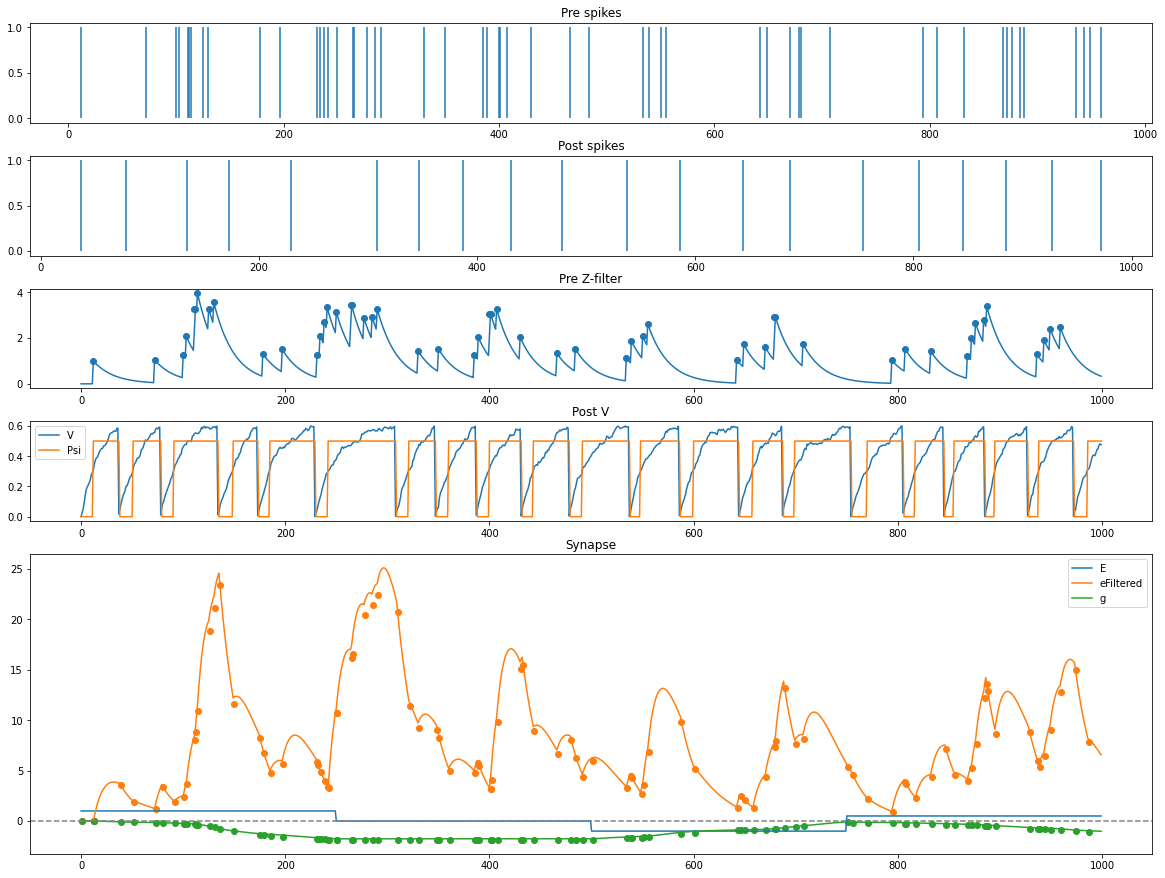

In [18]:
update_times = np.sort(np.concatenate((pre_spike_times, post_spike_event_times))).astype(int)

fig, axes = plt.subplots(5, figsize=(16, 12),
                         gridspec_kw={"height_ratios": [1, 1, 1, 1, 3]})
axes[0].set_title("Pre spikes")
axes[0].vlines(pre_spike_times, ymin=0, ymax=1)

axes[1].set_title("Post spikes")
axes[1].vlines(post_spike_times, ymin=0, ymax=1)

axes[2].set_title("Pre Z-filter")
z_filter_act = axes[2].plot(z_filter_pre_time)[0]
axes[2].scatter(pre_spike_times.astype(int), z_filter_pre_event[pre_spike_times.astype(int) + 1], color=z_filter_act.get_color())

axes[3].set_title("Post V")
axes[3].plot(v_post, label="V")
axes[3].plot(psi_post, label="Psi")
axes[3].legend()

axes[4].set_title("Synapse")
axes[4].plot(e, label="E")
e_act = axes[4].plot(e_filtered_time, label="eFiltered")[0]
g_act = axes[4].plot(g_time, label="g")[0]
axes[4].scatter(update_times + 1, e_filtered_event[update_times + 1], color=e_act.get_color())
axes[4].scatter(update_times + 1, g_event[update_times + 1], color=g_act.get_color())
axes[4].axhline(0, linestyle="--", color="gray")
axes[4].legend()
fig.tight_layout(pad=0)

